# 03 - Model Evaluation

This notebook provides comprehensive evaluation of the trained EEGNet model.

## Overview
- Load trained model checkpoint
- Evaluate on validation set
- Generate confusion matrix
- Analyze per-class performance
- Visualize prediction confidence
- Identify misclassifications

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from models.architectures.eegnet import EEGNet

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline


## 1. Load Configuration and Data

In [2]:
# Load configuration
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Get class names
class_mapping = config['preprocessing']['class_mapping']
class_names = [class_mapping[i] for i in range(len(class_mapping))]

print(f"Classes: {class_names}")

Classes: ['left', 'right', 'down', 'up']


In [3]:
class BCIDataset(Dataset):
    """PyTorch Dataset for BCI Competition data."""
    
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.X = self.X.unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
# Select subject (should match the one you trained)
subject_idx = 0  # 0: k3b, 1: k6b, 2: l1b
subject_file = config['paths']['subjects'][subject_idx]
subject_id = Path(subject_file).stem

print(f"Evaluating model for subject: {subject_id}")

# Load validation data
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
val_file = processed_dir / f"{subject_id}_val.npz"

if not val_file.exists():
    raise FileNotFoundError(
        f"Validation data not found: {val_file}"
    )

val_data = np.load(val_file)
X_val = val_data['X']
y_val = val_data['y']

print(f"Validation data: {X_val.shape}, Labels: {y_val.shape}")

Evaluating model for subject: k3b
Validation data: (36, 60, 1001), Labels: (36,)


In [5]:
# Create dataloader
val_dataset = BCIDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Validation batches: {len(val_loader)}")

Validation batches: 2


## 2. Load Trained Model

In [6]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model checkpoint
checkpoint_dir = PROJECT_ROOT / config['paths']['model_checkpoints']
checkpoint_path = checkpoint_dir / f"{subject_id}_best.pth"

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Model checkpoint not found: {checkpoint_path}\n"
        f"Train a model first using: 02_train_model.ipynb"
    )

checkpoint = torch.load(checkpoint_path, map_location=device)

# Create model
model = EEGNet(
    n_classes=config['model']['eegnet']['n_classes'],
    n_channels=config['model']['eegnet']['n_channels'],
    n_timepoints=config['model']['eegnet']['n_timepoints'],
    F1=config['model']['eegnet']['F1'],
    D=config['model']['eegnet']['D'],
    F2=config['model']['eegnet']['F2'],
    kernel_length=config['model']['eegnet']['kernel_length'],
    dropout=config['model']['eegnet']['dropout'],
    pool_size=config['model']['eegnet']['pool_size']
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Model loaded from epoch {checkpoint['epoch']+1}")
print(f"Training validation accuracy: {checkpoint['val_acc']:.4f}")

Using device: cpu
Model loaded from epoch 77
Training validation accuracy: 0.8889


## 3. Run Evaluation

In [7]:
# Evaluate model
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        probabilities = torch.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Evaluation complete")

Evaluation complete


## 4. Compute Metrics

In [8]:
# Overall accuracy
accuracy = accuracy_score(all_labels, all_predictions)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_predictions, average=None, zero_division=0
)

# Macro-averaged metrics
precision_avg, recall_avg, f1_avg, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average='macro', zero_division=0
)

# ROC AUC Score (One-vs-Rest for multi-class)
try:
    # Compute ROC AUC using One-vs-Rest approach
    auc_ovr = roc_auc_score(all_labels, all_probabilities, multi_class='ovr', average='macro')
    
    # Compute per-class AUC
    auc_per_class = roc_auc_score(all_labels, all_probabilities, multi_class='ovr', average=None)
except Exception as e:
    print(f"Warning: Could not compute AUC-ROC: {e}")
    auc_ovr = None
    auc_per_class = None

print("\n" + "="*60)
print("Evaluation Metrics")
print("="*60)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro Precision:  {precision_avg:.4f}")
print(f"Macro Recall:     {recall_avg:.4f}")
print(f"Macro F1 Score:   {f1_avg:.4f}")
if auc_ovr is not None:
    print(f"Macro AUC-ROC:    {auc_ovr:.4f}")
print("="*60)


Evaluation Metrics
Overall Accuracy: 0.8889
Macro Precision:  0.8990
Macro Recall:     0.8889
Macro F1 Score:   0.8882
Macro AUC-ROC:    0.9609


In [9]:
# Per-class metrics table
print("\nPer-Class Metrics:")
print("-" * 95)
print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'AUC-ROC':<12} {'Support':<12}")
print("-" * 95)

for i, class_name in enumerate(class_names):
    auc_str = f"{auc_per_class[i]:.4f}" if auc_per_class is not None else "N/A"
    print(f"{class_name:<20} {precision[i]:<12.4f} {recall[i]:<12.4f} "
          f"{f1[i]:<12.4f} {auc_str:<12} {support[i]:<12}")

print("-" * 95)
auc_avg_str = f"{auc_ovr:.4f}" if auc_ovr is not None else "N/A"
print(f"{'Average':<20} {precision_avg:<12.4f} {recall_avg:<12.4f} "
      f"{f1_avg:<12.4f} {auc_avg_str:<12} {support.sum():<12}")
print("-" * 95)


Per-Class Metrics:
-----------------------------------------------------------------------------------------------
Class                Precision    Recall       F1-Score     AUC-ROC      Support     
-----------------------------------------------------------------------------------------------
left                 1.0000       0.7778       0.8750       0.9712       9           
right                0.8182       1.0000       0.9000       0.9753       9           
down                 0.8889       0.8889       0.8889       0.9506       9           
up                   0.8889       0.8889       0.8889       0.9465       9           
-----------------------------------------------------------------------------------------------
Average              0.8990       0.8889       0.8882       0.9609       36          
-----------------------------------------------------------------------------------------------


## 5. Confusion Matrix

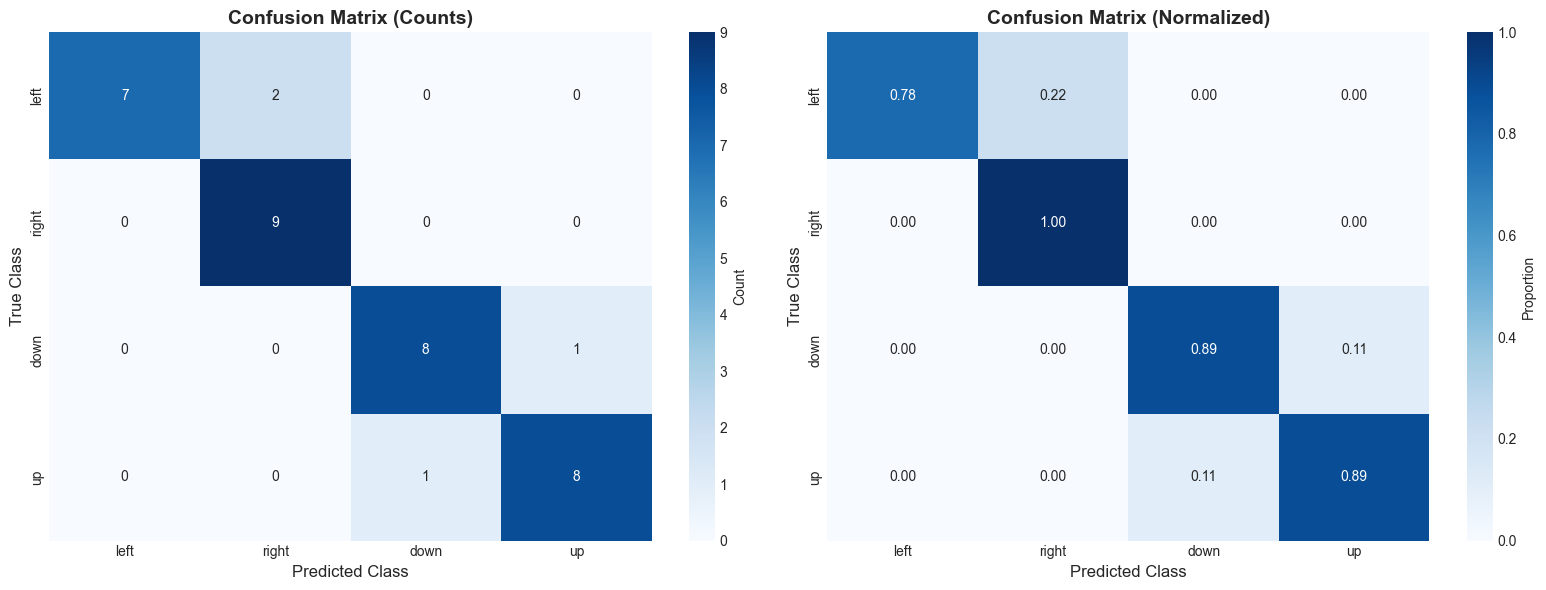

In [10]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax1)
ax1.set_xlabel('Predicted Class', fontsize=12)
ax1.set_ylabel('True Class', fontsize=12)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predicted Class', fontsize=12)
ax2.set_ylabel('True Class', fontsize=12)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. ROC Curves

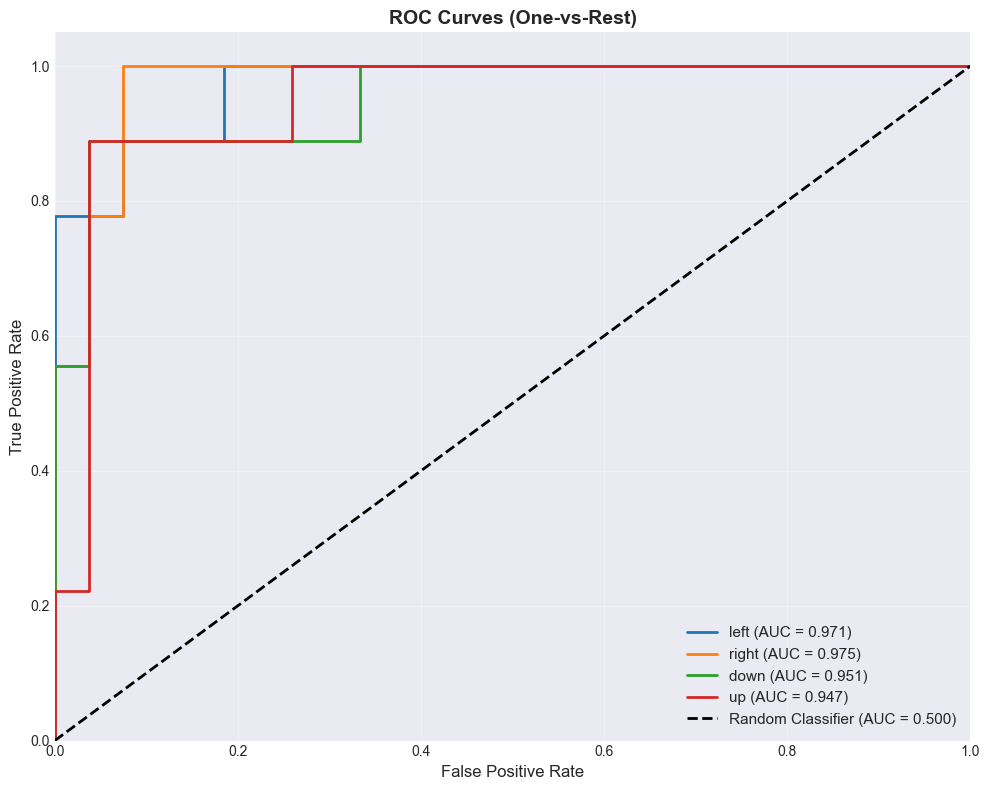


AUC-ROC Scores:
----------------------------------------
  left                : 0.9712
  right               : 0.9753
  down                : 0.9506
  up                  : 0.9465
----------------------------------------
  Macro Average       : 0.9609
----------------------------------------


In [11]:
# Compute ROC curve for each class (One-vs-Rest)
n_classes = len(class_names)

# Binarize the labels for ROC curve computation
y_bin = label_binarize(all_labels, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC scores
print("\nAUC-ROC Scores:")
print("-" * 40)
for i, class_name in enumerate(class_names):
    print(f"  {class_name:<20}: {roc_auc[i]:.4f}")
print("-" * 40)
if auc_ovr is not None:
    print(f"  {'Macro Average':<20}: {auc_ovr:.4f}")
print("-" * 40)

## 7. Prediction Confidence Analysis

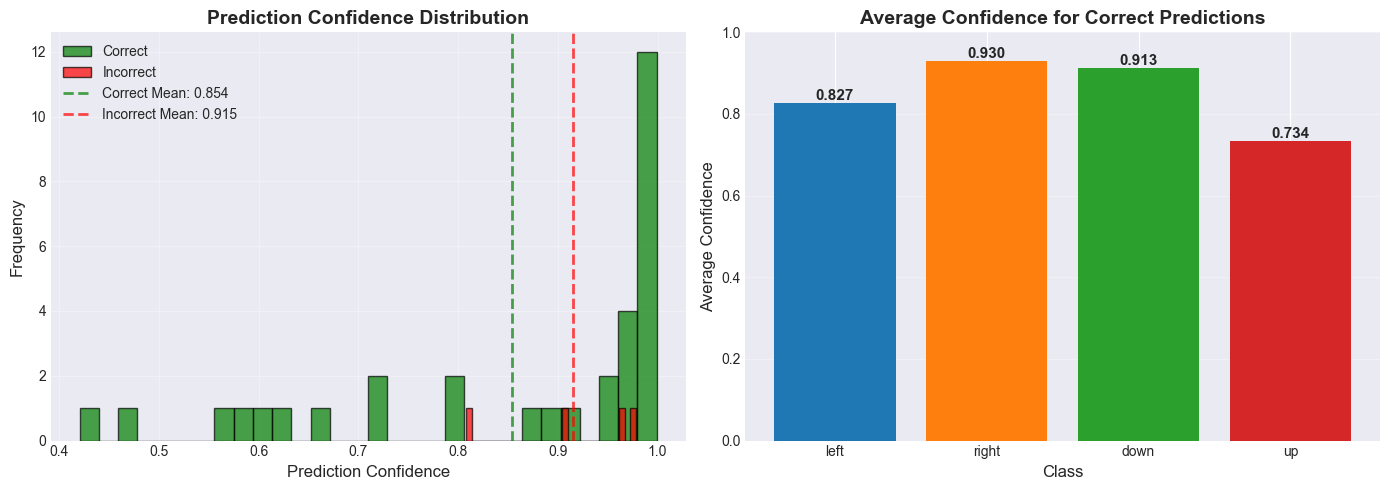

In [12]:
# Get max probabilities (confidence)
confidence = np.max(all_probabilities, axis=1)
correct_mask = all_labels == all_predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence distribution
ax1.hist(confidence[correct_mask], bins=30, alpha=0.7, label='Correct', 
         color='green', edgecolor='black')
ax1.hist(confidence[~correct_mask], bins=30, alpha=0.7, label='Incorrect', 
         color='red', edgecolor='black')
ax1.axvline(x=confidence[correct_mask].mean(), color='green', 
            linestyle='--', linewidth=2, alpha=0.7,
            label=f'Correct Mean: {confidence[correct_mask].mean():.3f}')
ax1.axvline(x=confidence[~correct_mask].mean(), color='red', 
            linestyle='--', linewidth=2, alpha=0.7,
            label=f'Incorrect Mean: {confidence[~correct_mask].mean():.3f}')
ax1.set_xlabel('Prediction Confidence', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Per-class confidence
confidence_per_class = []
for i in range(len(class_names)):
    class_mask = (all_labels == i) & correct_mask
    if class_mask.sum() > 0:
        confidence_per_class.append(confidence[class_mask].mean())
    else:
        confidence_per_class.append(0.0)

bars = ax2.bar(class_names, confidence_per_class,
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Average Confidence', fontsize=12)
ax2.set_title('Average Confidence for Correct Predictions', 
              fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, conf in zip(bars, confidence_per_class):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{conf:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Misclassification Analysis

In [13]:
# Find misclassified samples
misclassified_indices = np.where(~correct_mask)[0]
n_misclassified = len(misclassified_indices)

print(f"\nMisclassification Analysis")
print(f"Total misclassified: {n_misclassified} / {len(all_labels)} "
      f"({100*n_misclassified/len(all_labels):.2f}%)")

if n_misclassified > 0:
    # Most common misclassifications
    misclass_pairs = list(zip(
        all_labels[misclassified_indices],
        all_predictions[misclassified_indices]
    ))
    
    from collections import Counter
    misclass_counts = Counter(misclass_pairs)
    
    print(f"\nMost common misclassifications:")
    for (true_label, pred_label), count in misclass_counts.most_common(5):
        print(f"  {class_names[true_label]} → {class_names[pred_label]}: {count} times")
    
    # Show some misclassified examples
    print(f"\nSample misclassifications:")
    for idx in misclassified_indices[:5]:
        true_label = all_labels[idx]
        pred_label = all_predictions[idx]
        conf = confidence[idx]
        print(f"  Sample {idx}: True={class_names[true_label]}, "
              f"Predicted={class_names[pred_label]}, Confidence={conf:.3f}")
else:
    print("\nNo misclassifications - perfect accuracy")


Misclassification Analysis
Total misclassified: 4 / 36 (11.11%)

Most common misclassifications:
  left → right: 2 times
  up → down: 1 times
  down → up: 1 times

Sample misclassifications:
  Sample 13: True=up, Predicted=down, Confidence=0.978
  Sample 14: True=left, Predicted=right, Confidence=0.966
  Sample 17: True=left, Predicted=right, Confidence=0.808
  Sample 24: True=down, Predicted=up, Confidence=0.909


## 9. Save Evaluation Results

In [14]:
# Save results
results_dir = PROJECT_ROOT / "results" / subject_id
results_dir.mkdir(parents=True, exist_ok=True)

# Save metrics including AUC-ROC scores
metrics = {
    'accuracy': accuracy,
    'precision_avg': precision_avg,
    'recall_avg': recall_avg,
    'f1_avg': f1_avg,
    'auc_roc_avg': auc_ovr if auc_ovr is not None else 0.0,
    'precision_per_class': precision,
    'recall_per_class': recall,
    'f1_per_class': f1,
    'auc_roc_per_class': auc_per_class if auc_per_class is not None else np.zeros(len(class_names)),
    'support_per_class': support,
    'confusion_matrix': cm,
    'predictions': all_predictions,
    'labels': all_labels,
    'probabilities': all_probabilities
}

metrics_path = results_dir / "evaluation_metrics.npz"
np.savez(metrics_path, **metrics)

print(f"\nEvaluation results saved to: {metrics_path}")


Evaluation results saved to: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline\results\k3b\evaluation_metrics.npz


## 10. Summary

Model evaluation complete. Key findings:
- Overall accuracy and per-class performance metrics computed
- **AUC-ROC scores** calculated for multi-class classification
- Confusion matrix shows classification patterns
- **ROC curves** visualize class separability
- Confidence analysis reveals model certainty
- Misclassification patterns identified

**Next step**: Test model inference on individual samples using `04_model_inference.ipynb`